Libraries

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Paths

In [3]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR = "data/results/models"

# Join Results

## Queries

In [4]:
queries_rows = []

for file_name in os.listdir(QUERIES_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(QUERIES_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for metric in run.get("metrics", []):

                row = {
                    **base_info,

                    "query_description": metric.get("Query Description"),
                    "api_time_s": metric.get("API Time (s)"),
                    "sql_time_s": metric.get("SQL Time (s)"),
                    "time_delta": metric.get("Time Delta (SQL - API)")
                }

                queries_rows.append(row)

df_queries = pd.DataFrame(queries_rows)

## Models

In [5]:
models_rows = []

for file_name in os.listdir(MODELS_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(MODELS_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for result in run.get("model_results", []):

                metrics = result.get("metrics", {})

                row = {
                    **base_info,

                    "model_name": result.get("model_name"),
                    "target": result.get("target"),
                    "task_type": result.get("task_type"),

                    "rmse": metrics.get("rmse"),
                    "r2": metrics.get("r2"),
                    "mae": metrics.get("mae"),
                    "mse": metrics.get("mse"),

                    "execution_time_seconds": result.get("execution_time_seconds")
                }

                models_rows.append(row)

df_models = pd.DataFrame(models_rows)

## Preview

In [6]:
print("\n==============================")
print("QUERIES DATAFRAME")
print("==============================")
print(df_queries.head())

print("\nShape:", df_queries.shape)

print("\n==============================")
print("MODELS DATAFRAME")
print("==============================")
print(df_models.head())

print("\nShape:", df_models.shape)


QUERIES DATAFRAME
             timestamp spark_mode  executor_instances  executor_cores  \
0  2026-05-18 22:31:06   baseline                   2               1   
1  2026-05-18 22:31:06   baseline                   2               1   
2  2026-05-18 22:31:06   baseline                   2               1   
3  2026-05-18 22:31:06   baseline                   2               1   
4  2026-05-18 22:31:06   baseline                   2               1   

  executor_memory  shuffle_partitions  adaptive  \
0              3g                  50     False   
1              3g                  50     False   
2              3g                  50     False   
3              3g                  50     False   
4              3g                  50     False   

                         query_description  api_time_s  sql_time_s  time_delta  
0  Q1.1: Borough Revenue vs Tip Percentage      9.1348      6.9593     -2.1755  
1            Q1.2: Tip Paradox by Distance      6.5489      6.4698     -0

In [7]:
df_queries

,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,query_description,api_time_s,sql_time_s,time_delta
0,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.1: Borough Revenue vs Tip Percentage,9.1348,6.9593,-2.1755
1,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.2: Tip Paradox by Distance,6.5489,6.4698,-0.0791
2,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.3: Revenue Composition,1.8494,1.3900,-0.4594
3,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.4: Payment Method Impact,5.6741,5.2889,-0.3852
4,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.5: Passenger Count Impact,6.0691,5.7165,-0.3525
...,...,...,...,...,...,...,...,...,...,...,...
459,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q4.9: Monthly Evolution of Average Revenue by ...,1.9353,1.1644,-0.7710
460,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.1: Hourly Analysis of Taxi Operations,2.1709,1.5224,-0.6485
461,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.2: Analysis of Non-Revenue Trips and Disput...,1.6022,1.4541,-0.1482
462,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.3: The Inverse Relationship Between Revenue...,1.6781,1.4429,-0.2352


In [8]:
df_models

,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,model_name,target,task_type,rmse,r2,mae,mse,execution_time_seconds
0,2026-05-16 16:29:08,baseline,2,1,3g,50,False,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,623.91
1,2026-05-16 16:29:08,baseline,2,1,3g,50,False,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,506.73
2,2026-05-16 17:06:30,balanced,2,2,4g,100,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,496.94
3,2026-05-16 17:06:30,balanced,2,2,4g,100,True,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,496.84
4,2026-05-16 17:28:00,high_parallelism,3,2,4g,150,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,494.11
5,2026-05-16 17:28:00,high_parallelism,3,2,4g,150,True,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,493.12
6,2026-05-16 17:46:49,memory_optimized,2,1,6g,100,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,490.76
7,2026-05-16 17:46:49,memory_optimized,2,1,6g,100,True,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,495.77
8,2026-05-16 18:06:44,stress_test,4,2,3g,200,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,492.65
9,2026-05-16 18:06:44,stress_test,4,2,3g,200,True,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,492.83


### **Queries Performance Analysis**

1. Grouped Bar Chart by Category — API vs SQL, faceted by Q1…Q5, with error bars (std) and % gain annotation of SQL over API
2. Time Delta (SQL − API) — sorted horizontal bars, green = SQL wins, red = API wins, with Δ value annotated on each bar
3. Spark Mode Config Impact — grouped bars per config + Query × spark_mode heatmap showing API execution time
4. Categories + Ranking — box plots per category (Q1–Q5) with annotated medians + stacked horizontal ranking (API + SQL) from fastest to slowest

#### Style

In [15]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlepad"     : 10,
})

C_API = "#7BA3D4"   # pastel blue   → Spark API
C_SQL = "#F2B48A"   # pastel orange → SQL
C_POS = "#F08080"   # pastel red    → API is faster (Δ > 0)
C_NEG = "#7CC97C"   # pastel green  → SQL is faster (Δ < 0)

CAT_COLORS = {
    "Q1": "#7BA3D4",   # pastel blue
    "Q2": "#F2B48A",   # pastel orange
    "Q3": "#7CC97C",   # pastel green
    "Q4": "#C3A8E0",   # pastel purple
    "Q5": "#C9A098",   # pastel brown
}

CAT_NAMES = {
    "Q1": "Billing and Tips",
    "Q2": "Geographic Patterns",
    "Q3": "Temporal Dynamics",
    "Q4": "Special Rates and Airports",
    "Q5": "Efficiency and Operations",
}

#### Preparation

In [16]:
df = df_queries.copy()

df["category"] = df["query_description"].str.extract(r"(Q\d)")
df["query_id"]  = df["query_description"].str.extract(r"(Q\d+\.\d+)")

# Average per query across all spark_modes
df_avg = (
    df.groupby(["query_id", "category"], as_index=False)
      .agg(
          api_mean   = ("api_time_s",  "mean"),
          api_std    = ("api_time_s",  "std"),
          sql_mean   = ("sql_time_s",  "mean"),
          sql_std    = ("sql_time_s",  "std"),
          delta_mean = ("time_delta",  "mean"),
      )
      .sort_values("query_id")
      .reset_index(drop=True)
)
df_avg["faster"]  = np.where(df_avg["sql_mean"] < df_avg["api_mean"], "SQL", "API")
df_avg["speedup"] = df_avg["api_mean"] / df_avg["sql_mean"]   # >1 → SQL is faster

# Average per spark_mode
df_mode = (
    df.groupby("spark_mode", as_index=False)
      .agg(
          api_mean = ("api_time_s", "mean"),
          api_std  = ("api_time_s", "std"),
          sql_mean = ("sql_time_s", "mean"),
          sql_std  = ("sql_time_s", "std"),
      )
)

# Long format for seaborn
df_long = df.melt(
    id_vars    = ["category", "query_id", "spark_mode"],
    value_vars = ["api_time_s", "sql_time_s"],
    var_name   = "type",
    value_name = "time_s",
)
df_long["type"] = df_long["type"].map({"api_time_s": "Spark API", "sql_time_s": "SQL"})

cats  = sorted(df["category"].unique())
modes = df["spark_mode"].unique()

print("✔  Setup complete")
print(f"   {len(df_avg)} unique queries | {len(modes)} spark_modes | {len(cats)} categories")
sql_faster = (df_avg["faster"] == "SQL").sum()
print(f"   SQL faster in {sql_faster}/{len(df_avg)} queries (global average)\n")

LEGEND = [
    mpatches.Patch(color=C_API, label="Spark API"),
    mpatches.Patch(color=C_SQL, label="SQL"),
]

✔  Setup complete
   29 unique queries | 8 spark_modes | 5 categories
   SQL faster in 27/29 queries (global average)



1. Grouped Bar Chart by Category — API vs SQL, faceted by Q1…Q5, with error bars (std) and % gain annotation of SQL over API

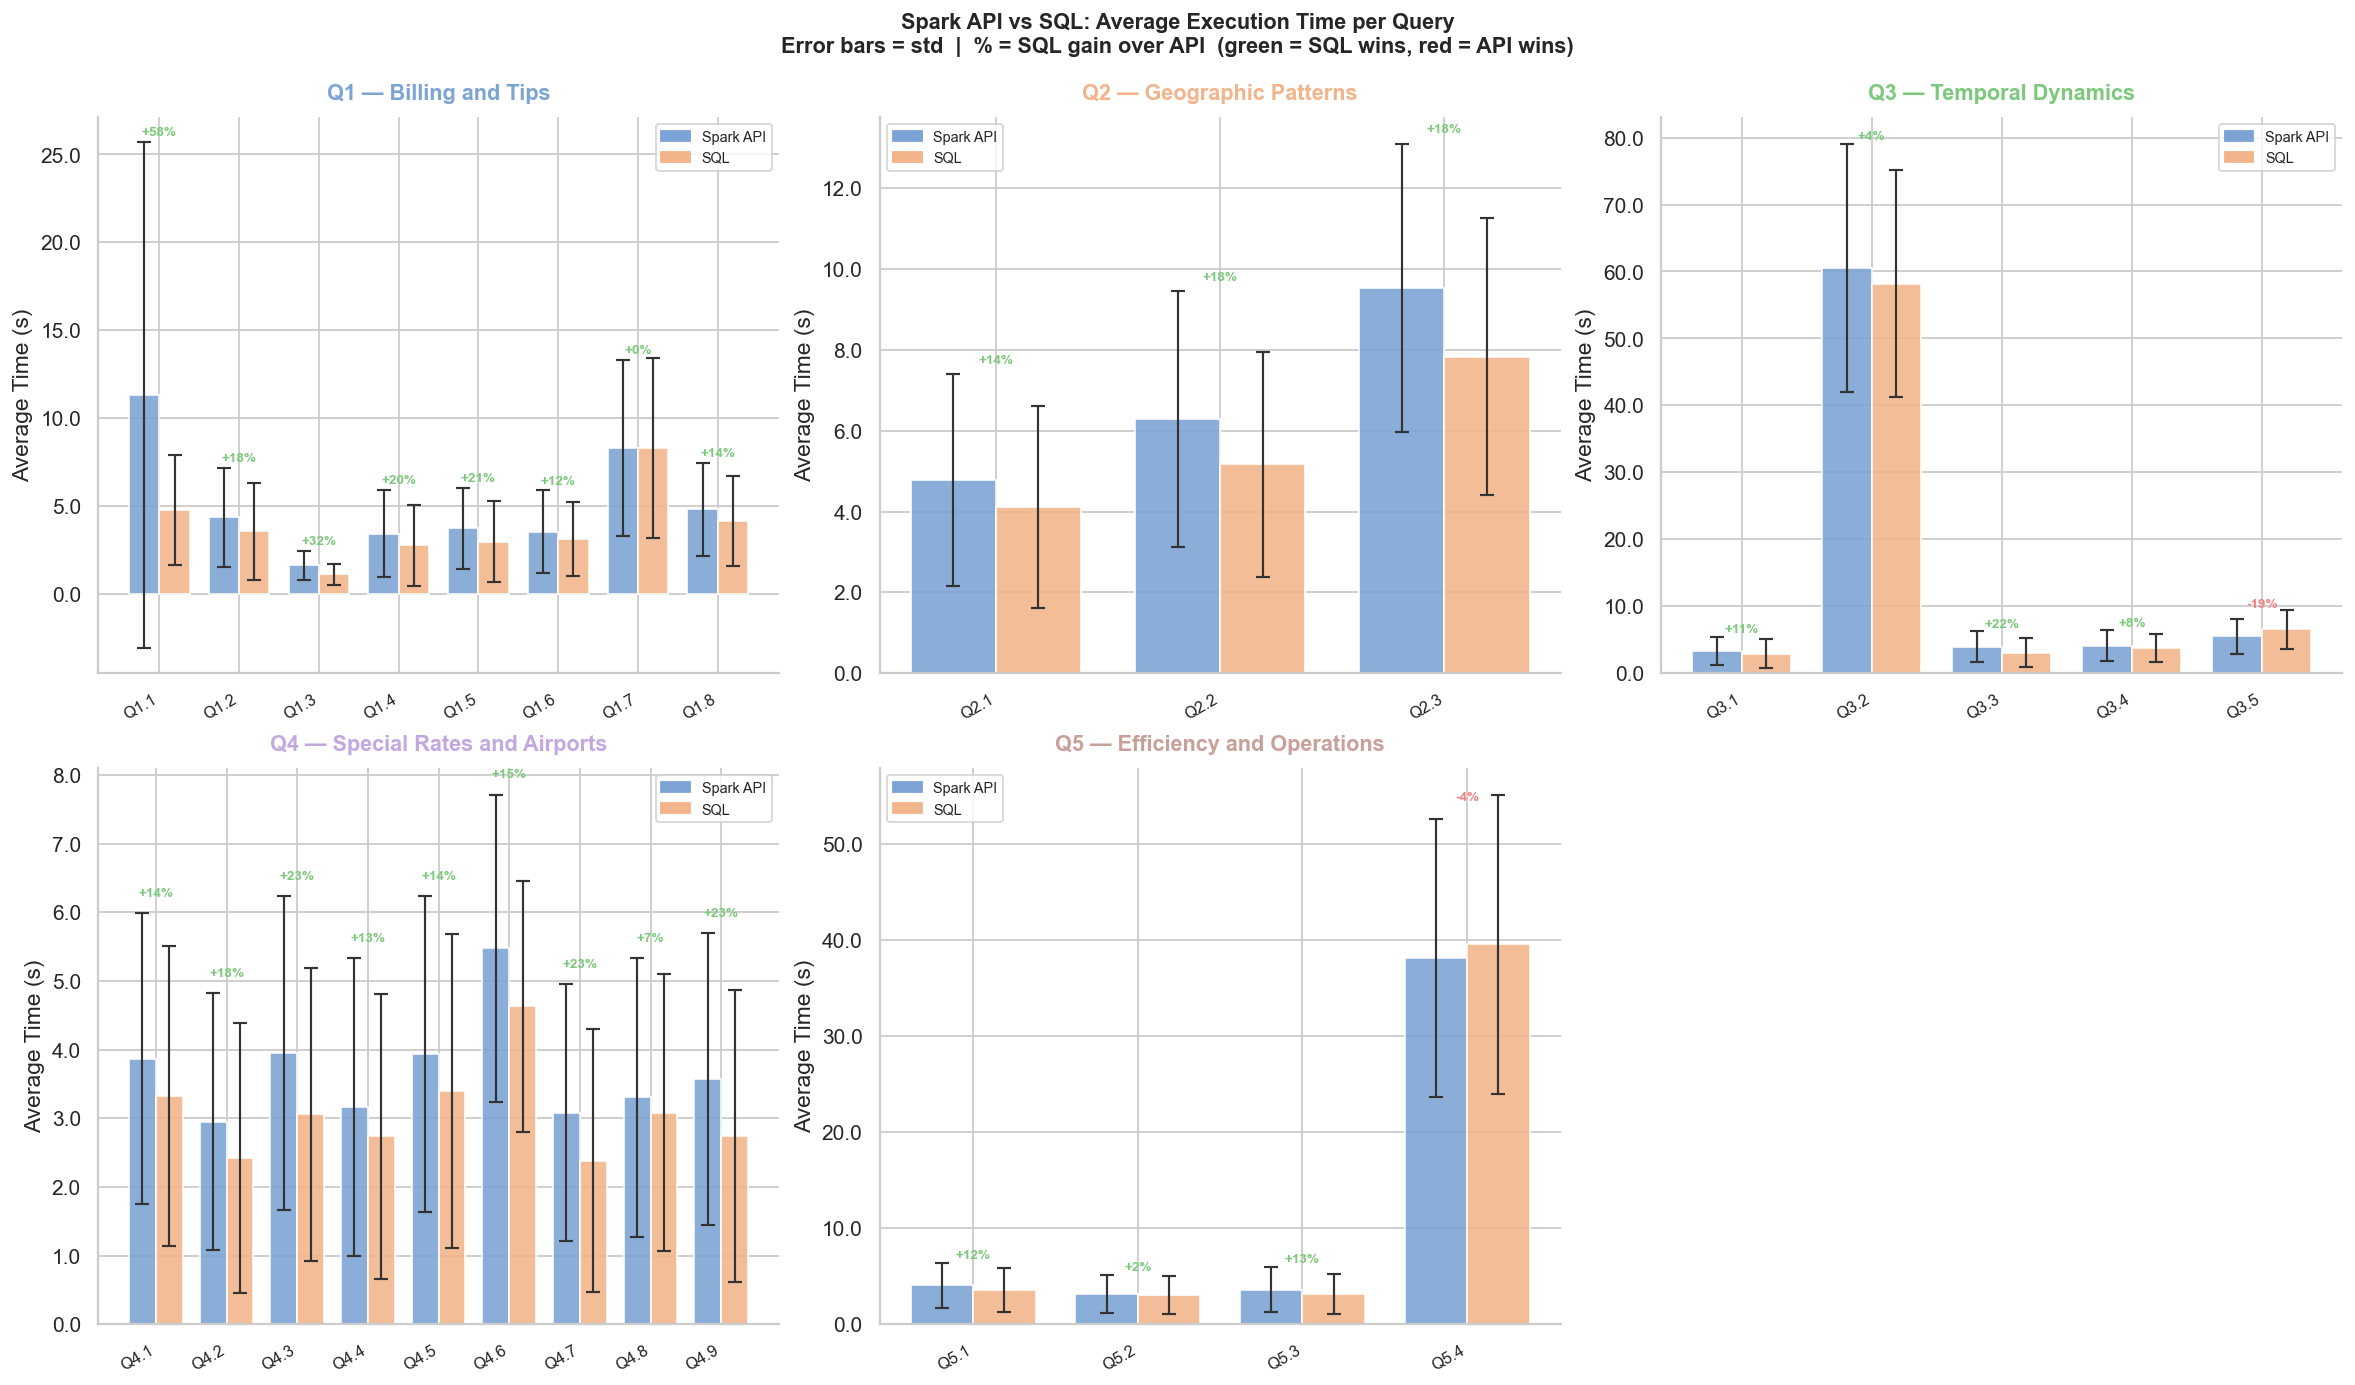

In [27]:
n_cols = 3
n_rows = int(np.ceil(len(cats) / n_cols))

fig1, axes1 = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 5 * n_rows),
    constrained_layout=True,
)
axes1 = axes1.flatten()

LEGEND_LOC = {
    "Q1": "upper right",
    "Q2": "upper left",
    "Q3": "upper right",
    "Q4": "upper right",
    "Q5": "upper left",
}

for i, cat in enumerate(cats):
    ax  = axes1[i]
    sub = df_avg[df_avg["category"] == cat].reset_index(drop=True)
    x   = np.arange(len(sub))
    w   = 0.38

    ax.bar(x - w/2, sub["api_mean"], w,
           yerr=sub["api_std"], capsize=4, color=C_API, alpha=0.88,
           error_kw=dict(elinewidth=1.2, ecolor="#333", capthick=1.2))
    ax.bar(x + w/2, sub["sql_mean"], w,
           yerr=sub["sql_std"], capsize=4, color=C_SQL, alpha=0.88,
           error_kw=dict(elinewidth=1.2, ecolor="#333", capthick=1.2))

    # Annotate % gain of SQL over API
    for j, row in sub.iterrows():
        pct = (row["api_mean"] - row["sql_mean"]) / row["api_mean"] * 100
        top = max(row["api_mean"], row["sql_mean"]) + (row["api_std"] or 0) + 0.2
        clr = C_NEG if pct > 0 else C_POS
        ax.text(j, top, f"{pct:+.0f}%", ha="center", va="bottom",
                fontsize=7.5, color=clr, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["query_id"], rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{cat} — {CAT_NAMES.get(cat, cat)}", fontsize=12, fontweight="bold",
                 color=CAT_COLORS.get(cat, "black"))
    ax.set_ylabel("Average Time (s)")
    ax.legend(handles=LEGEND, fontsize=8, loc=LEGEND_LOC.get(cat, "upper right"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)

fig1.suptitle(
    "Spark API vs SQL: Average Execution Time per Query\n"
    "Error bars = std  |  % = SQL gain over API  (green = SQL wins, red = API wins)",
    fontsize=12, fontweight="bold", y=1.05,
)


plt.show()

2. Time Delta (SQL − API) — sorted horizontal bars, green = SQL wins, red = API wins, with Δ value annotated on each bar

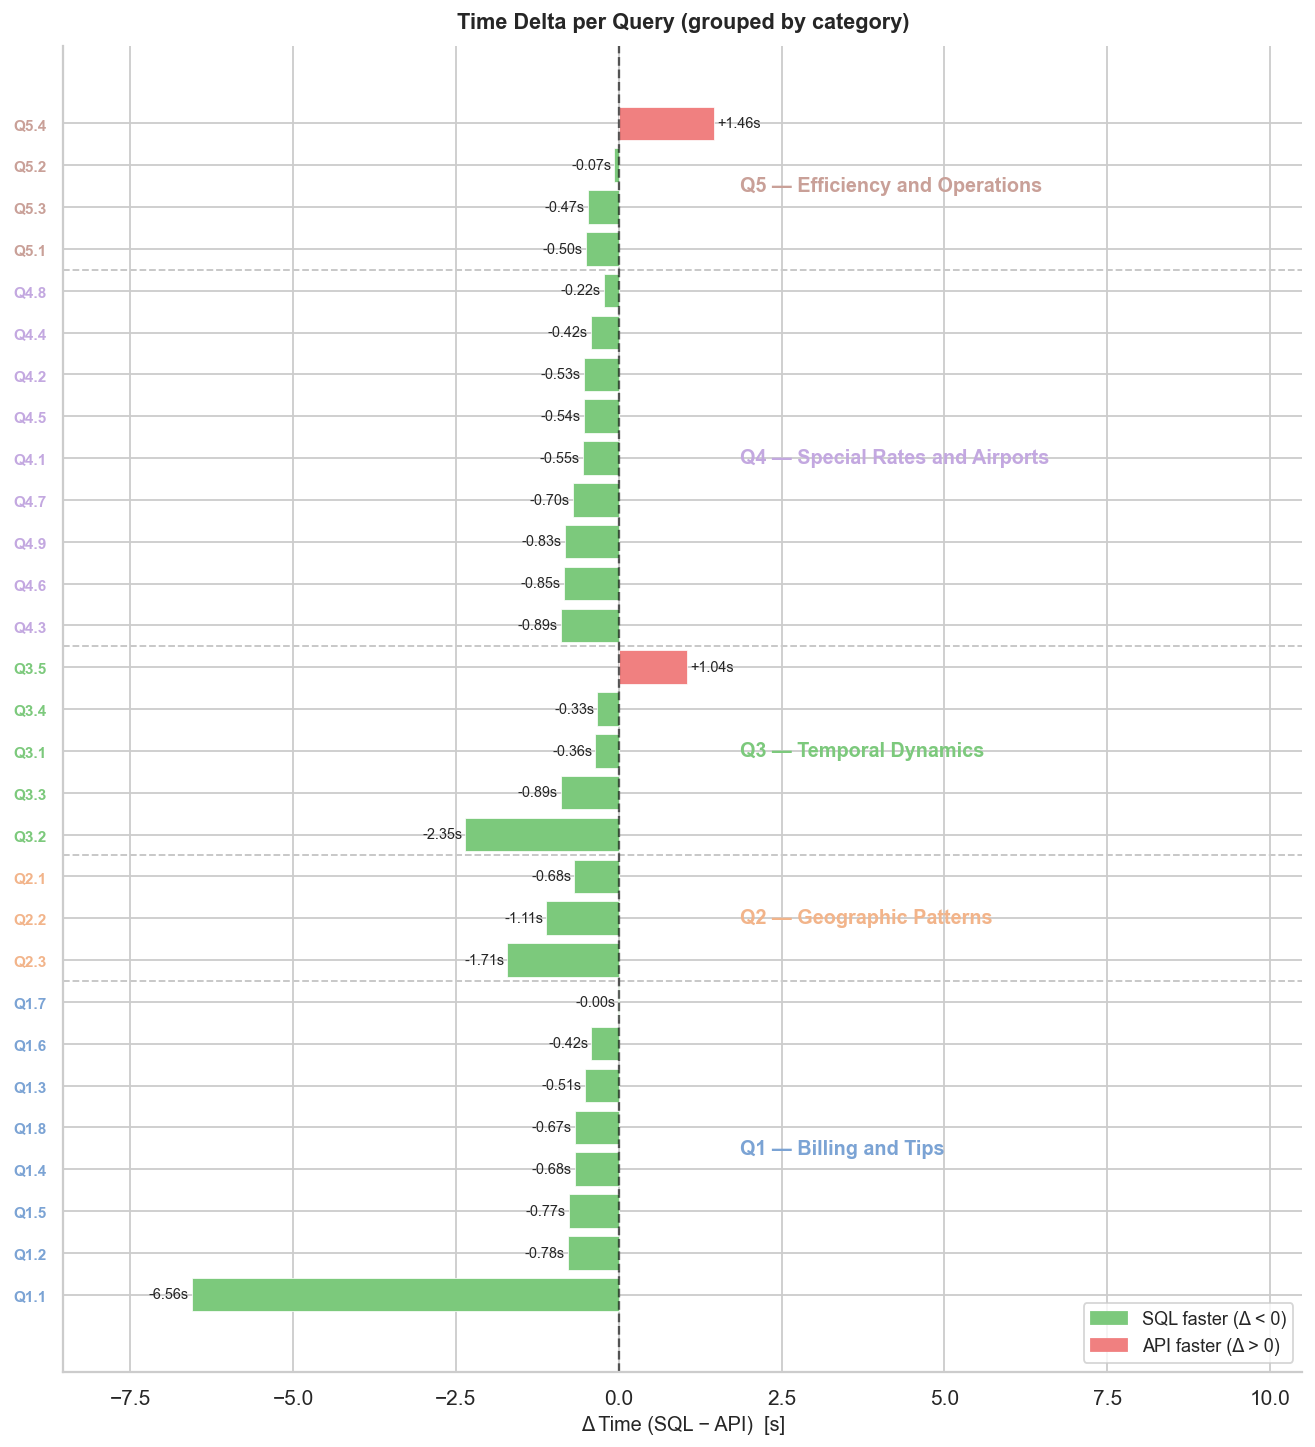

In [34]:
df_delta = (
    df_avg.sort_values(["category", "delta_mean"])
          .reset_index(drop=True)
)
bar_colors = [C_NEG if d < 0 else C_POS for d in df_delta["delta_mean"]]

fig2, ax2 = plt.subplots(figsize=(10, max(6, len(df_delta) * 0.38)),
                          constrained_layout=True)

bars = ax2.barh(range(len(df_delta)), df_delta["delta_mean"],
                color=bar_colors, edgecolor="white", linewidth=0.4)

ax2.axvline(0, color="black", linewidth=1.3, linestyle="--", alpha=0.6)
ax2.set_xlabel("Δ Time (SQL − API)  [s]", fontsize=11)
ax2.set_title(
    "Time Delta per Query (grouped by category)",
    fontsize=12, fontweight="bold",
)

ax2.set_yticks(range(len(df_delta)))
ax2.set_yticklabels(df_delta["query_id"], fontsize=8.5)
for label, (_, row) in zip(ax2.get_yticklabels(), df_delta.iterrows()):
    label.set_color(CAT_COLORS.get(row["category"], "black"))
    label.set_fontweight("bold")

cat_groups = df_delta.groupby("category", sort=False)
boundaries = {}
for cat, grp in df_delta.groupby("category", sort=True):
    boundaries[cat] = (grp.index[0], grp.index[-1])

for cat, (start, end) in boundaries.items():
    if start > 0:
        ax2.axhline(start - 0.5, color="#aaa", linewidth=1.0,
                    linestyle="--", alpha=0.7, zorder=0)
    mid = (start + end) / 2
    ax2.text(ax2.get_xlim()[1] if ax2.get_xlim()[1] != 0 else df_delta["delta_mean"].abs().max() + 0.3,
         mid, f"{cat} — {CAT_NAMES.get(cat, '')}",
         va="center", ha="left", fontsize=11,
         color=CAT_COLORS.get(cat, "black"), fontweight="bold",
         transform=ax2.get_yaxis_transform() if False else ax2.transData)

for bar, val in zip(bars, df_delta["delta_mean"]):
    offset = 0.05 if val >= 0 else -0.05
    ha     = "left"  if val >= 0 else "right"
    ax2.text(val + offset, bar.get_y() + bar.get_height() / 2,
             f"{val:+.2f}s", va="center", ha=ha, fontsize=8)

patch_sql = mpatches.Patch(color=C_NEG, label="SQL faster (Δ < 0)")
patch_api = mpatches.Patch(color=C_POS, label="API faster (Δ > 0)")
ax2.legend(handles=[patch_sql, patch_api], fontsize=10, loc="lower right")

x_max = df_delta["delta_mean"].abs().max()
ax2.set_xlim(left=-(x_max * 1.3))
ax2.set_xlim(right=x_max * 1.6)

plt.show()

3. Spark Mode Config Impact — grouped bars per config + Query × spark_mode heatmap showing API execution time

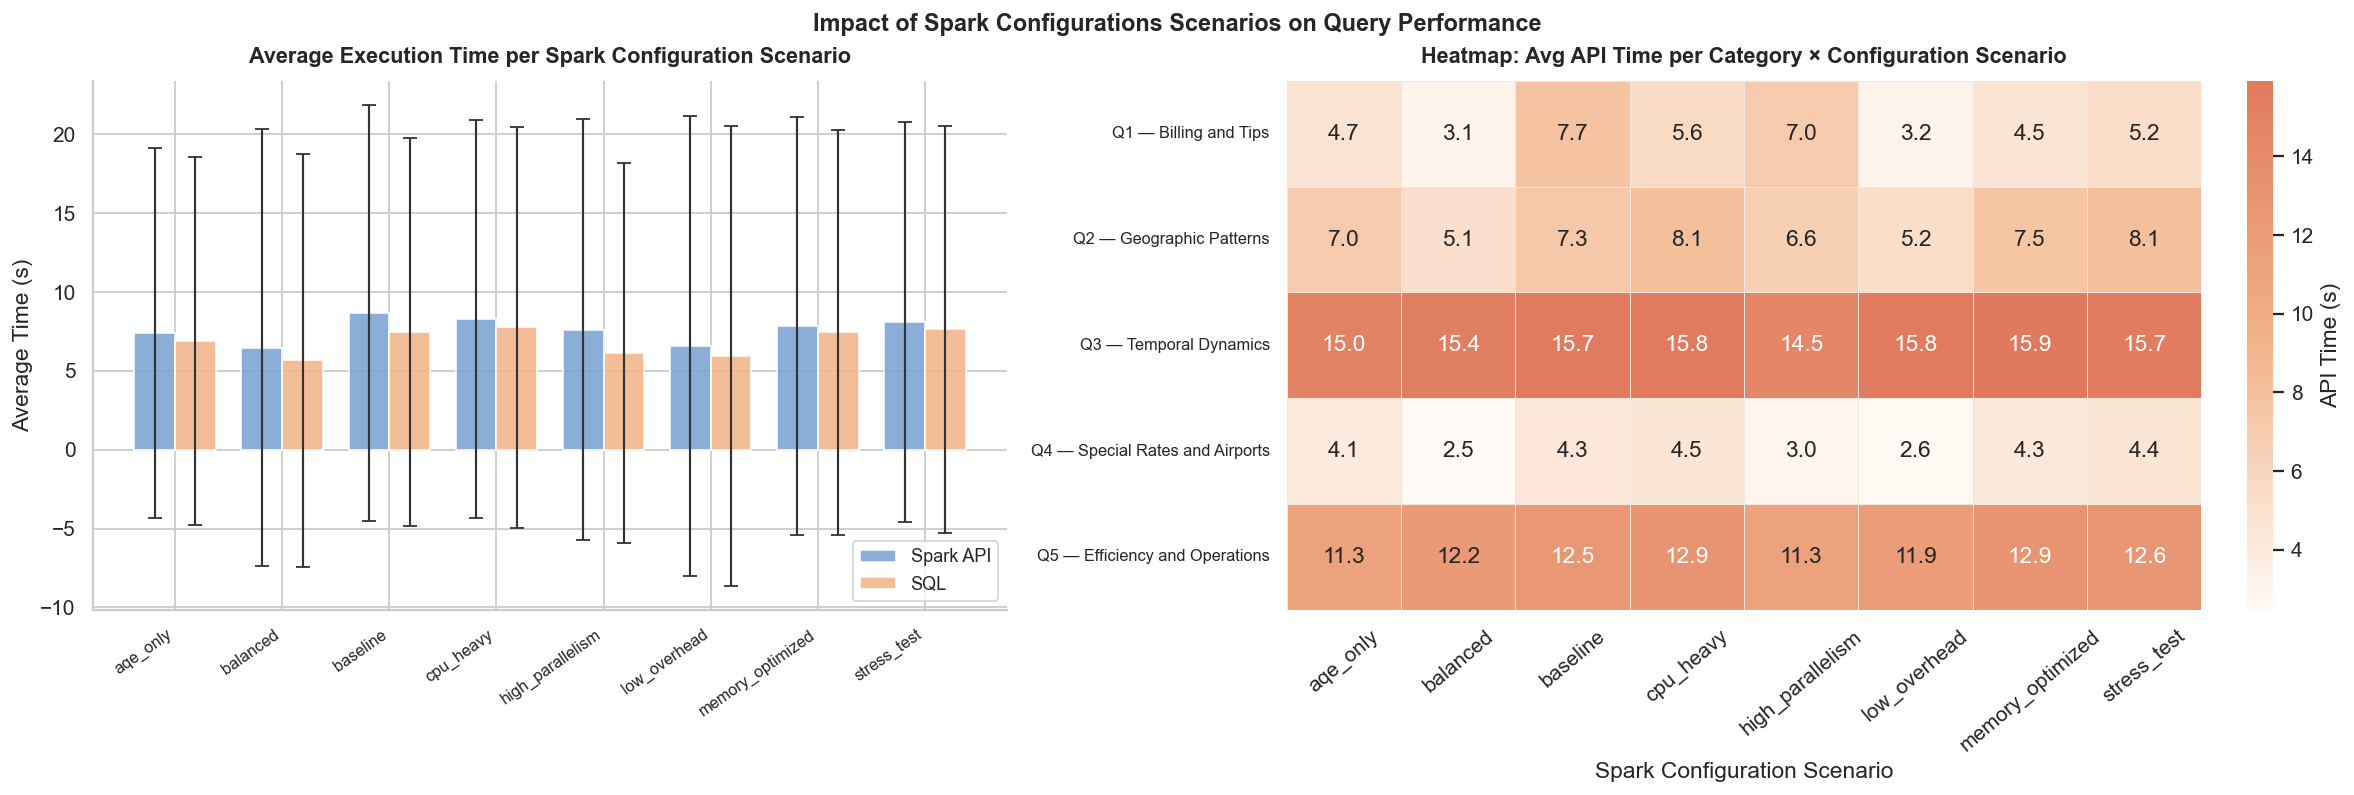

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

pastel_cmap = LinearSegmentedColormap.from_list(
    "pastel_warm", ["#fffaf5", "#F2B48A", "#e07a5f"]
)

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# ── 3A: Grouped bars per spark_mode ──────────────────────────────────────────
ax3a = axes3[0]
x3   = np.arange(len(df_mode))
w3   = 0.38

ax3a.bar(x3 - w3/2, df_mode["api_mean"], w3,
         yerr=df_mode["api_std"], capsize=4,
         color=C_API, alpha=0.88, label="Spark API",
         error_kw=dict(elinewidth=1.2, ecolor="#333"))
ax3a.bar(x3 + w3/2, df_mode["sql_mean"], w3,
         yerr=df_mode["sql_std"], capsize=4,
         color=C_SQL, alpha=0.88, label="SQL",
         error_kw=dict(elinewidth=1.2, ecolor="#333"))

ax3a.set_xticks(x3)
ax3a.set_xticklabels(df_mode["spark_mode"], rotation=35, ha="right", fontsize=9)
ax3a.set_ylabel("Average Time (s)")
ax3a.set_title("Average Execution Time per Spark Configuration Scenario", fontsize=12, fontweight="bold")
ax3a.legend(fontsize=10)

# ── 3B: Heatmap Query × spark_mode (API time) ────────────────────────────────
ax3b = axes3[1]

pivot_cat = df.pivot_table(index="category", columns="spark_mode",
                            values="api_time_s", aggfunc="mean")
pivot_cat = pivot_cat.loc[sorted(pivot_cat.index)]

pivot_cat.index = [f"{cat} — {CAT_NAMES.get(cat, cat)}" for cat in pivot_cat.index]

sns.heatmap(
    pivot_cat, ax=ax3b,
    cmap=pastel_cmap,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="#f0e8e0",
    cbar_kws={"label": "API Time (s)"},
)
ax3b.set_title("Heatmap: Avg API Time per Category × Configuration Scenario",
               fontsize=12, fontweight="bold")
ax3b.set_xlabel("Spark Configuration Scenario")
ax3b.set_ylabel("")
ax3b.tick_params(axis="x", rotation=40)
ax3b.tick_params(axis="y", rotation=0, labelsize=9)

fig3.suptitle(
    "Impact of Spark Configurations Scenarios on Query Performance",
    fontsize=13, fontweight="bold",
)
plt.show()

4. Categories + Ranking — box plots per category (Q1–Q5) with annotated medians + stacked horizontal ranking (API + SQL) from fastest to slowest

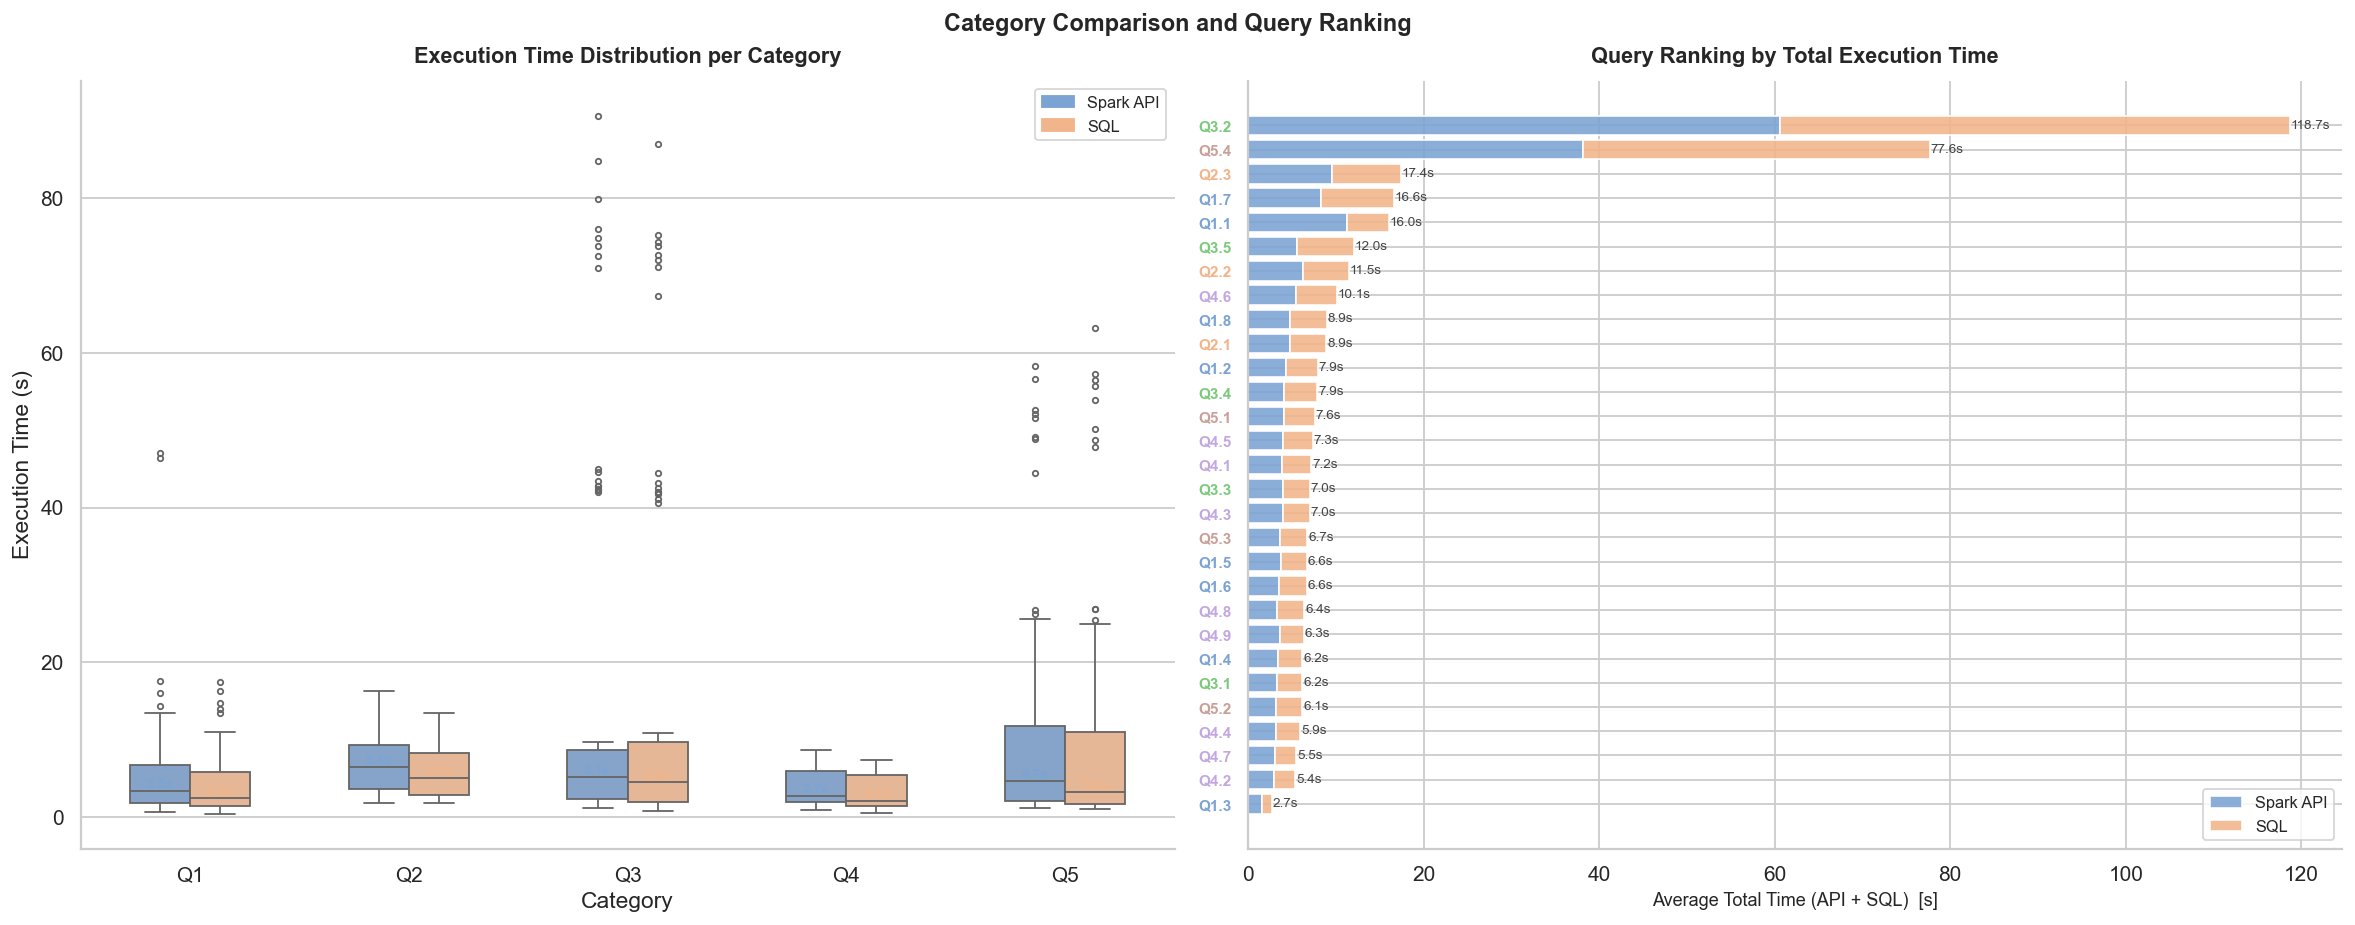

In [48]:
fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# ── 4A: Box plots per category ────────────────────────────────────────────────
ax4a = axes4[0]
sns.boxplot(
    data=df_long,
    x="category", y="time_s", hue="type",
    palette={"Spark API": C_API, "SQL": C_SQL},
    width=0.55, fliersize=3,
    legend=False,
    ax=ax4a,
)
ax4a.set_title("Execution Time Distribution per Category", fontsize=12, fontweight="bold")
ax4a.set_xlabel("Category")
ax4a.set_ylabel("Execution Time (s)")
ax4a.legend(
    handles=[
        mpatches.Patch(color=C_API, label="Spark API"),
        mpatches.Patch(color=C_SQL, label="SQL"),
    ],
    fontsize=9,
    loc="upper right",
)

for i, cat in enumerate(sorted(df_long["category"].unique())):
    for j, tipo in enumerate(["Spark API", "SQL"]):
        vals = df_long[(df_long["category"] == cat) & (df_long["type"] == tipo)]["time_s"]
        med  = vals.median()
        x_pos = i + (j - 0.5) * 0.28
        ax4a.text(x_pos, med, f"{med:.1f}s",
                  ha="center", va="bottom", fontsize=7.5, fontweight="bold",
                  color=C_API if tipo == "Spark API" else C_SQL)

# ── 4B: Ranking horizontal (stacked API + SQL) ────────────────────────────────
ax4b = axes4[1]
df_rank = df_avg.copy()
df_rank["avg_total"] = df_rank["api_mean"] + df_rank["sql_mean"]
df_rank = df_rank.sort_values("avg_total", ascending=True).reset_index(drop=True)

y_pos = np.arange(len(df_rank))

ax4b.barh(y_pos, df_rank["api_mean"],
          color=C_API, alpha=0.88, label="Spark API")
ax4b.barh(y_pos, df_rank["sql_mean"],
          color=C_SQL, alpha=0.88, left=df_rank["api_mean"], label="SQL")

ax4b.set_yticks(y_pos)
ax4b.set_yticklabels(df_rank["query_id"], fontsize=8.5)

# Color each y label by its category
for label, (_, row) in zip(ax4b.get_yticklabels(), df_rank.iterrows()):
    label.set_color(CAT_COLORS.get(row["category"], "black"))
    label.set_fontweight("bold")

ax4b.set_xlabel("Average Total Time (API + SQL)  [s]", fontsize=10)
ax4b.set_title(
    "Query Ranking by Total Execution Time",
    fontsize=12, fontweight="bold",
)
ax4b.legend(fontsize=9, loc="lower right")

# Annotate total time at the end of each bar
for y, row in zip(y_pos, df_rank.itertuples()):
    ax4b.text(row.avg_total + 0.1, y, f"{row.avg_total:.1f}s",
              va="center", ha="left", fontsize=7.5, color="#444")

fig4.suptitle(
    "Category Comparison and Query Ranking",
    fontsize=13, fontweight="bold",
)
plt.show()

Statistical Summary

In [50]:
print("\n" + "=" * 60)
print("RESUMO GLOBAL")
print("=" * 60)
print(f"  Queries analisadas        : {len(df_avg)}")
print(f"  SQL mais rápida           : {(df_avg['faster']=='SQL').sum()} queries")
print(f"  API mais rápida           : {(df_avg['faster']=='API').sum()} queries")
print(f"  Speedup médio (API/SQL)   : {df_avg['speedup'].mean():.3f}×")
print(f"  Query mais lenta (API)    : {df_avg.loc[df_avg['api_mean'].idxmax(), 'query_id']}"
      f"  ({df_avg['api_mean'].max():.2f}s)")
print(f"  Query mais lenta (SQL)    : {df_avg.loc[df_avg['sql_mean'].idxmax(), 'query_id']}"
      f"  ({df_avg['sql_mean'].max():.2f}s)")
print(f"  Maior ganho SQL           : {df_avg.loc[df_avg['delta_mean'].idxmin(), 'query_id']}"
      f"  (Δ = {df_avg['delta_mean'].min():.2f}s)")
print("=" * 60)


RESUMO GLOBAL
  Queries analisadas        : 29
  SQL mais rápida           : 27 queries
  API mais rápida           : 2 queries
  Speedup médio (API/SQL)   : 1.206×
  Query mais lenta (API)    : Q3.2  (60.55s)
  Query mais lenta (SQL)    : Q3.2  (58.20s)
  Maior ganho SQL           : Q1.1  (Δ = -6.56s)


### **Models Performance Analysis**

1. Radar Chart — R², 1/RMSE, 1/MAE and Speed normalised per target, one polygon per model
2. Quadrant Scatter — R² vs Exec Time with 4 quadrants (Ideal / Slow but accurate / Fast but weak / Avoid), bubble size proportional to inverted MAE, whiskers showing time variation across configs
3. Bump Chart — exec time ranking per spark_mode, crossing lines reveal models that benefit from specific configurations
4. Parallel Coordinates — Instances → Cores → Memory → Partitions → Adaptive → Exec Time, thick lines = best config per model
5. Dumbbell Chart — RMSE (●) vs MAE (■) per model and gap Δ

####  Style

In [64]:
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlepad"     : 10,
})

MODEL_PALETTE = sns.color_palette("tab10", 20)

MODEL_COLORS = {
    "LinearRegression_Ridge_Std" : "#7BA3D4",   # pastel blue
    "DecisionTreeRegressor"      : "#F2B48A",   # pastel orange
    "GeneralizedLinearModel"     : "#C3A8E0",   # pastel purple
}

METRIC_COLORS = {
    "r2"   : "#7CC97C",   # pastel green  → higher is better
    "rmse" : "#F08080",   # pastel red    → lower is better
    "mae"  : "#FFD580",   # pastel yellow → lower is better
    "mse"  : "#C9A098",   # pastel brown  → lower is better
}

TARGET_STYLE  = {
    "total_amount"     : dict(marker="o", ls="-"),
    "trip_duration_min": dict(marker="s", ls="--"),
}

#### Preparation

In [65]:
df = df_models.copy()
df["memory_gb"]    = df["executor_memory"].str.extract(r"(\d+)").astype(int)
df["adaptive_int"] = df["adaptive"].astype(int)

models   = sorted(df["model_name"].unique())
targets  = sorted(df["target"].unique())
modes    = sorted(df["spark_mode"].unique())
n_models = len(models)

# Short names for labels (first 2 parts of name split by _)
def short(name, max_parts=2):
    parts = name.split("_")
    return "_".join(parts[:max_parts])

SHORT = {m: short(m) for m in models}

# ── Average per model × target (across all spark_modes) ──────────────────────
df_mta = (
    df.groupby(["model_name", "target"], as_index=False)
      .agg(
          r2_mean   = ("r2",   "mean"),
          rmse_mean = ("rmse", "mean"),
          mae_mean  = ("mae",  "mean"),
          mse_mean  = ("mse",  "mean"),
          time_mean = ("execution_time_seconds", "mean"),
          time_std  = ("execution_time_seconds", "std"),
          time_min  = ("execution_time_seconds", "min"),
          time_max  = ("execution_time_seconds", "max"),
      )
)

# ── Per model × spark_mode × target (for bump chart + parallel coords) ────────
df_mst = (
    df.groupby(["model_name", "spark_mode", "target"], as_index=False)
      .agg(
          time               = ("execution_time_seconds", "mean"),
          r2                 = ("r2",                     "first"),
          mae                = ("mae",                    "first"),
          executor_instances = ("executor_instances",     "first"),
          executor_cores     = ("executor_cores",         "first"),
          memory_gb          = ("memory_gb",              "first"),
          shuffle_partitions = ("shuffle_partitions",     "first"),
          adaptive_int       = ("adaptive_int",           "first"),
      )
)

print("✔  Setup complete")
print(f"   {n_models} models | {len(modes)} configs | {len(targets)} targets\n")

✔  Setup complete
   3 models | 8 configs | 2 targets



1. Radar Chart — R², 1/RMSE, 1/MAE and Speed normalised per target, one polygon per model

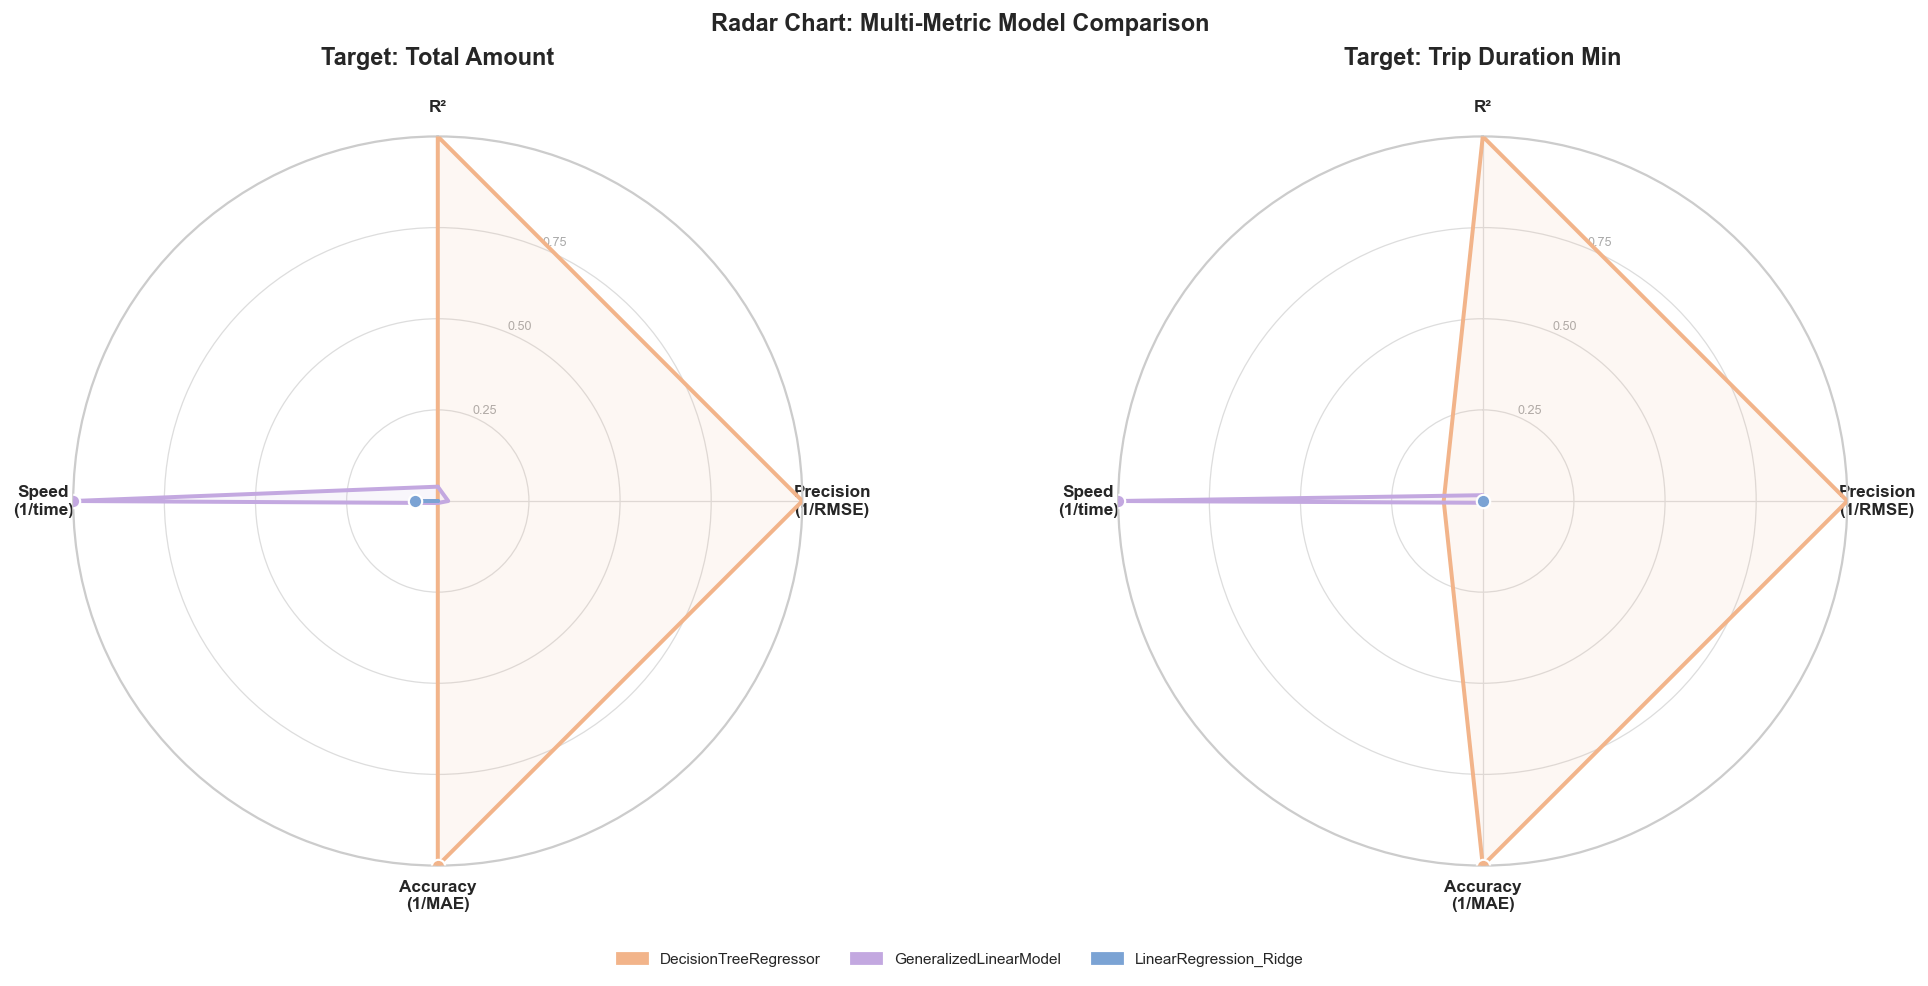

In [69]:
RADAR_LABELS = ["R²", "Precision\n(1/RMSE)", "Accuracy\n(1/MAE)", "Speed\n(1/time)"]

def build_radar(sub):
    """Returns dict metric→normalised array (shape: n_models,), best model = 1."""
    raw = {
        "R²"               : sub["r2_mean"].values.copy(),
        "Precision\n(1/RMSE)": 1.0 / sub["rmse_mean"].values,
        "Accuracy\n(1/MAE)": 1.0 / sub["mae_mean"].values,
        "Speed\n(1/time)"  : 1.0 / sub["time_mean"].values,
    }
    normed = {}
    for k, v in raw.items():
        mn, mx = v.min(), v.max()
        normed[k] = (v - mn) / (mx - mn + 1e-12)
    return normed

fig1, axes1 = plt.subplots(
    1, len(targets),
    figsize=(8 * len(targets), 7),
    subplot_kw=dict(polar=True),
    constrained_layout=True,
)
if len(targets) == 1:
    axes1 = [axes1]

for ax, tgt in zip(axes1, targets):
    sub    = df_mta[df_mta["target"] == tgt].reset_index(drop=True)
    mnames = sub["model_name"].tolist()
    normed = build_radar(sub)

    N        = len(RADAR_LABELS)
    angles   = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles_c = np.append(angles, angles[0])
    vals_all = np.array(list(normed.values())).T   # (n_models, N)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(RADAR_LABELS, fontsize=9.5, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=7, color="#aaa")
    ax.yaxis.grid(True, color="#ddd", linewidth=0.7)
    ax.xaxis.grid(True, color="#ddd", linewidth=0.7)
    ax.spines["polar"].set_color("#ccc")

    for m, vals in zip(mnames, vals_all):
        v   = np.append(vals, vals[0])
        clr = MODEL_COLORS.get(m, "#999999")
        ax.plot(angles_c, v, color=clr, linewidth=2.2, zorder=3)
        ax.fill(angles_c, v, color=clr, alpha=0.10, zorder=2)
        best_i = int(np.argmax(vals))
        ax.scatter(angles[best_i], vals[best_i], s=55, color=clr, zorder=6,
                   edgecolors="white", linewidths=1.2)

    tgt_label = tgt.replace("_", " ").title()
    ax.set_title(f"Target: {tgt_label}", fontsize=13, fontweight="bold", pad=40)

legend_hdls = [mpatches.Patch(color=MODEL_COLORS.get(m, "#999"), label=SHORT[m])
               for m in models]
fig1.legend(handles=legend_hdls, loc="lower center",
            ncol=min(6, n_models), fontsize=8.5,
            bbox_to_anchor=(0.5, -0.07), frameon=False)
fig1.suptitle(
    "Radar Chart: Multi-Metric Model Comparison",
    fontsize=13, fontweight="bold",
)
plt.show()

2. Quadrant Scatter — R² vs Exec Time with 4 quadrants (Ideal / Slow but accurate / Fast but weak / Avoid), bubble size proportional to inverted MAE, whiskers showing time variation across configs

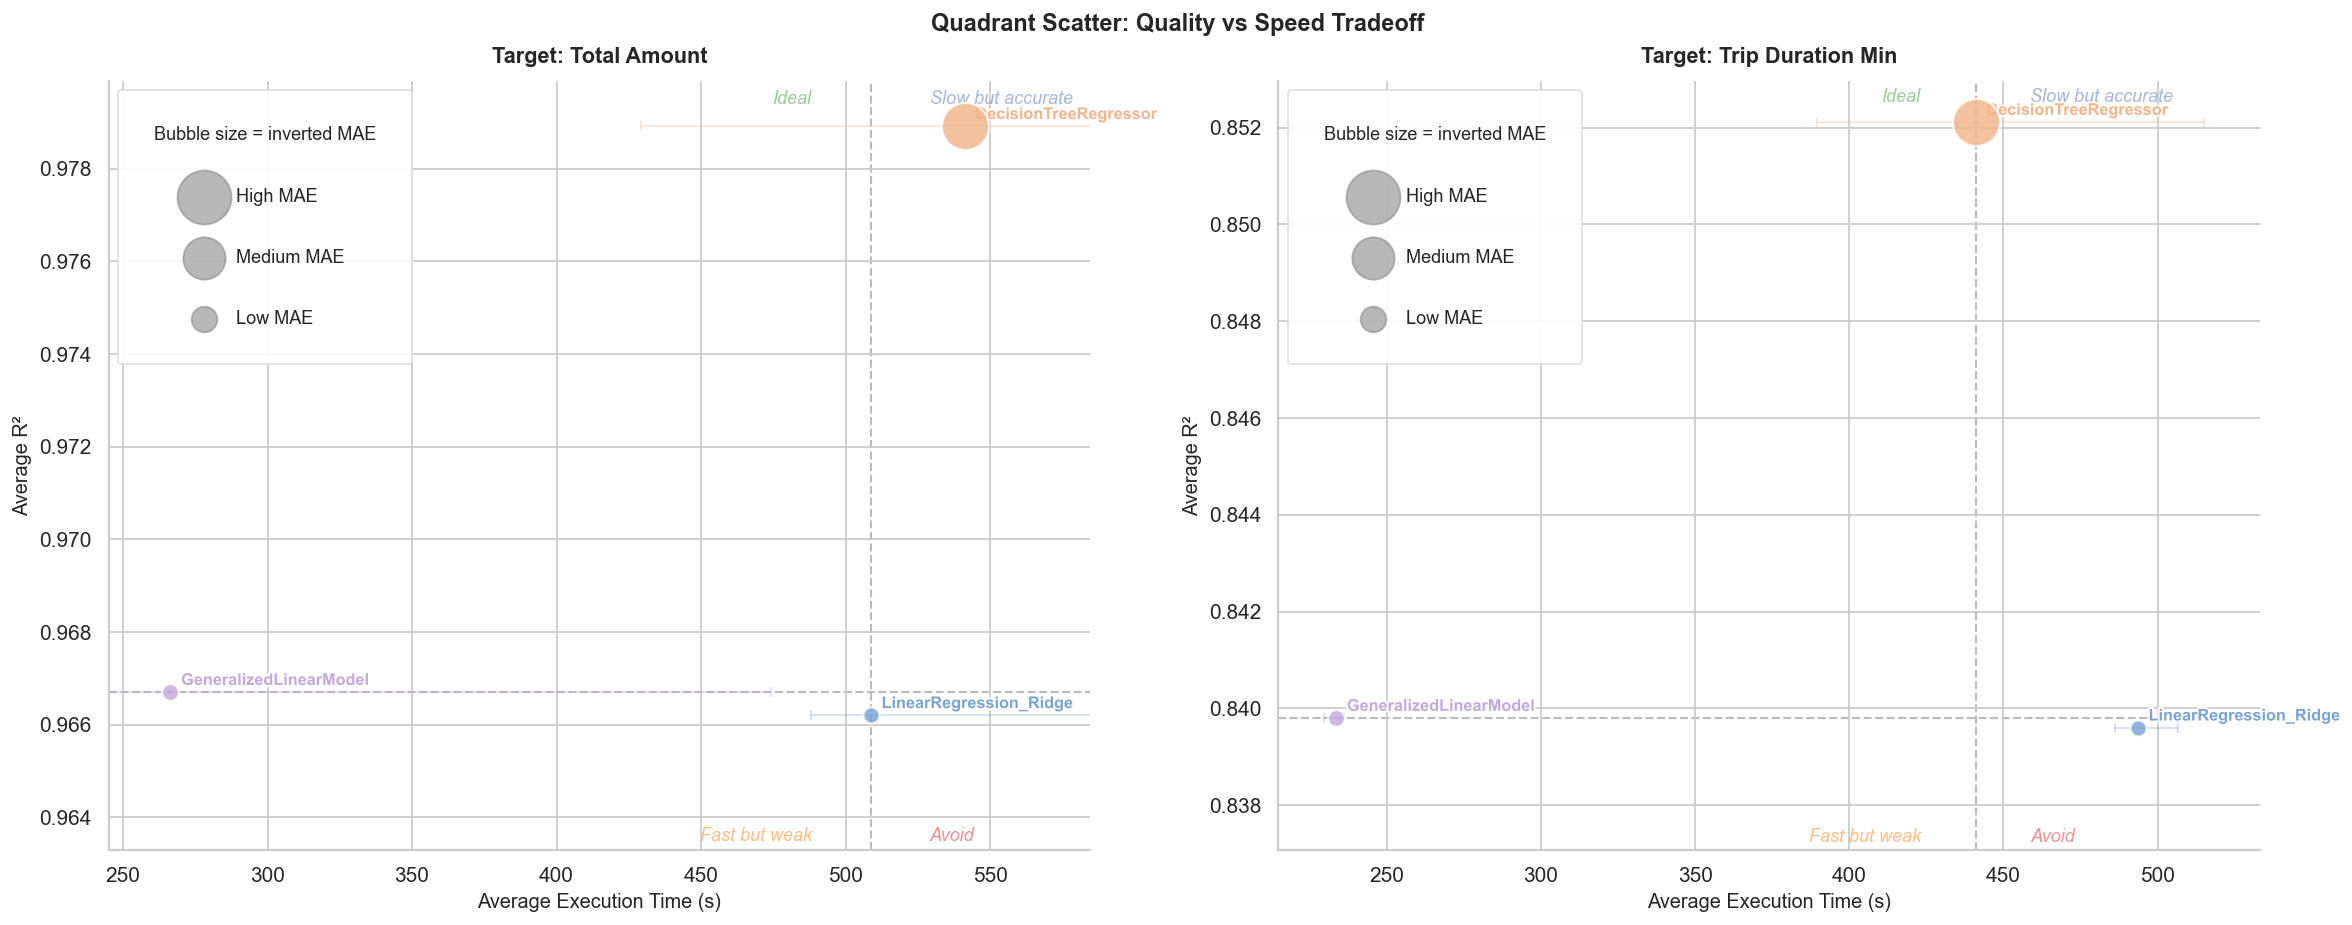

In [90]:
fig2, axes2 = plt.subplots(
    1, len(targets),
    figsize=(9 * len(targets), 7),
    constrained_layout=True,
)
if len(targets) == 1:
    axes2 = [axes2]

for ax, tgt in zip(axes2, targets):
    sub  = df_mta[df_mta["target"] == tgt].reset_index(drop=True)
    x    = sub["time_mean"].values
    y    = sub["r2_mean"].values
    mae  = sub["mae_mean"].values

    # Bubble size: smaller MAE → larger bubble (better)
    mae_norm = (mae - mae.min()) / (mae.max() - mae.min() + 1e-12)
    sizes    = (1 - mae_norm) * 600 + 80

    # Quadrant lines (medians)
    xm, ym = np.median(x), np.median(y)
    ax.axvline(xm, color="#bbb", linestyle="--", linewidth=1.2, zorder=0)
    ax.axhline(ym, color="#bbb", linestyle="--", linewidth=1.2, zorder=0)

    # Quadrant shading
    xlim = (x.min() * 0.92, x.max() * 1.08)
    ylim = (y.min() * 0.997, min(y.max() * 1.001, 1.002))

    # Quadrant labels
    tx_kw = dict(fontsize=10, alpha=0.5, fontstyle="italic")
    ax.text(xm * 0.96, ylim[1] * 0.9995, "Ideal",            ha="right", color="#2ca02c", **tx_kw)
    ax.text(xm * 1.04, ylim[1] * 0.9995, "Slow but accurate",   ha="left",  color="#4C72B0", **tx_kw)
    ax.text(xm * 0.96, ylim[0] * 1.0002, "Fast but weak",       ha="right", color="#ff7f0e", **tx_kw)
    ax.text(xm * 1.04, ylim[0] * 1.0002, "Avoid",             ha="left",  color="#d62728", **tx_kw)

    # Scatter
    for i, row in sub.iterrows():
        clr = MODEL_COLORS.get(row["model_name"], "#999999")
        ax.scatter(x[i], y[i], s=sizes[i], color=clr,
                   alpha=0.82, edgecolors="white", linewidths=1.2, zorder=4)
        ax.annotate(
            SHORT[row["model_name"]],
            xy=(x[i], y[i]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=9.0, color=clr, fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
        )
        ax.errorbar(x[i], y[i],
                    xerr=[[x[i] - row["time_min"]], [row["time_max"] - x[i]]],
                    fmt="none", color=clr, alpha=0.35, linewidth=1, capsize=3)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Average Execution Time (s)", fontsize=11)
    ax.set_ylabel("Average R²", fontsize=11)
    tgt_label = tgt.replace("_", " ").title()
    ax.set_title(f"Target: {tgt_label}", fontsize=12, fontweight="bold")

    # Bubble size legend
    for pct, lbl in zip([0.1, 0.5, 0.9], ["High MAE", "Medium MAE", "Low MAE"]):
        s = (1 - pct) * 600 + 80
        ax.scatter([], [], s=s, color="#888", alpha=0.6, label=lbl)
    ax.legend(title="Bubble size = inverted MAE", fontsize=10, title_fontsize=10,
              loc="upper left", markerscale=1.2,
              framealpha=0.9, edgecolor="#ddd",
              borderpad=2, labelspacing=2.4)

fig2.suptitle(
    "Quadrant Scatter: Quality vs Speed Tradeoff",
    fontsize=13, fontweight="bold",
)
plt.show()

3. Bump Chart — exec time ranking per spark_mode, crossing lines reveal models that benefit from specific configurations

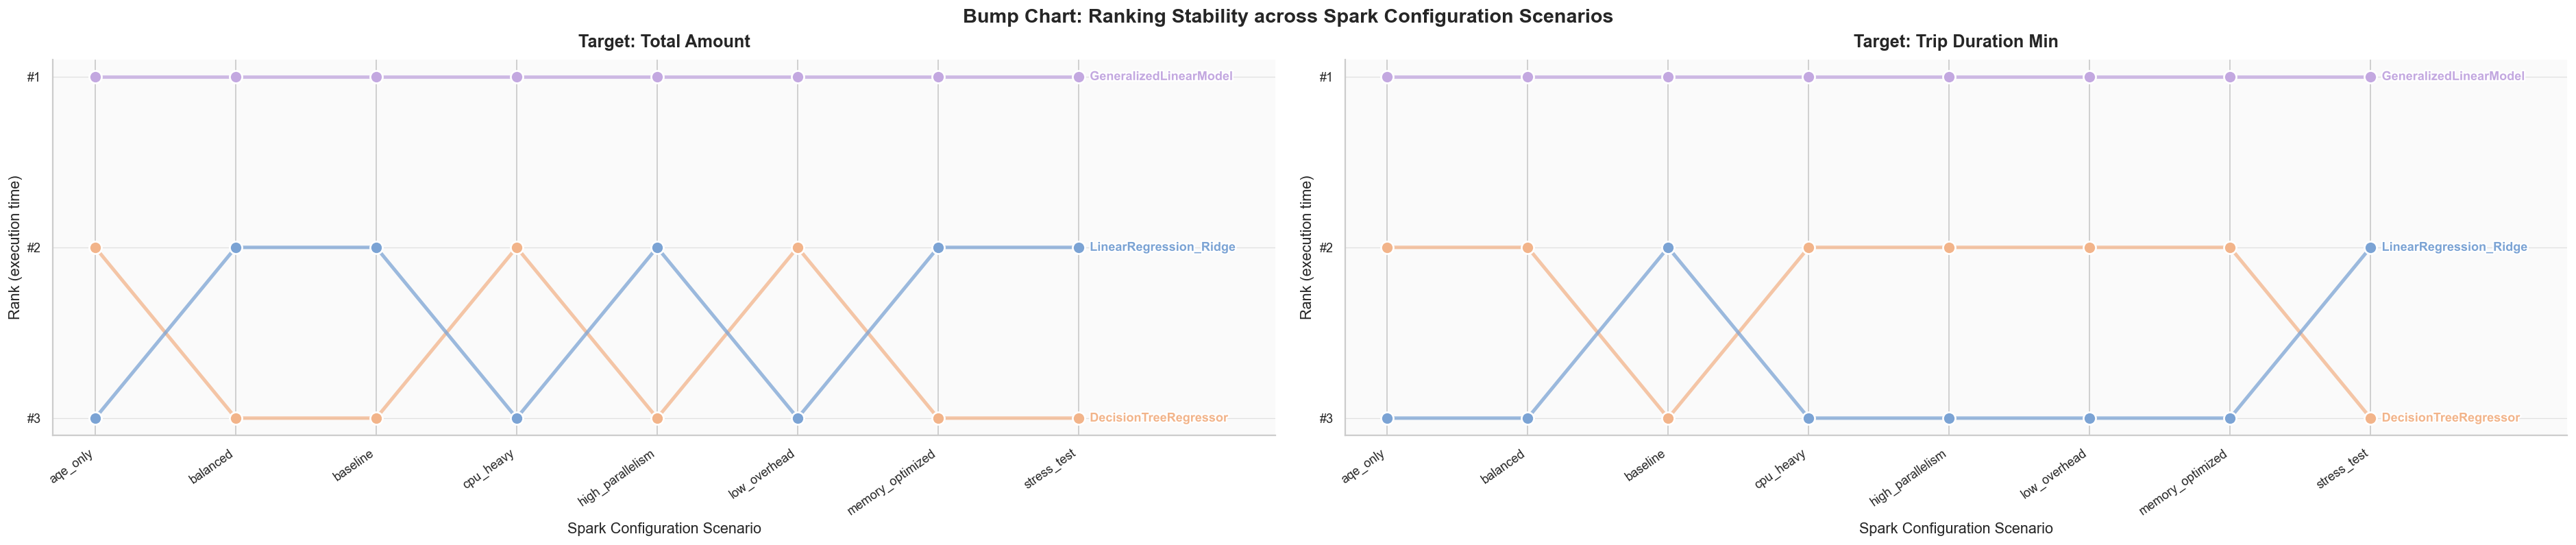

In [99]:
fig3, axes3 = plt.subplots(
    1, len(targets),
    figsize=(max(10, len(modes) * 1.8) * len(targets), max(6, n_models * 0.7)),
    constrained_layout=True,
)
if len(targets) == 1:
    axes3 = [axes3]

for ax, tgt in zip(axes3, targets):
    sub = df_mst[df_mst["target"] == tgt].copy()

    sub["rank"]     = sub.groupby("spark_mode")["time"].rank(method="min", ascending=True)
    sub["mode_idx"] = sub["spark_mode"].map({m: i for i, m in enumerate(modes)})

    ax.set_facecolor("#fafafa")
    ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.7, zorder=0)

    for model in models:
        msub = sub[sub["model_name"] == model].sort_values("mode_idx")
        if msub.empty:
            continue
        clr = MODEL_COLORS.get(model, "#999999")
        xs  = msub["mode_idx"].values
        ys  = msub["rank"].values

        ax.plot(xs, ys, color=clr, linewidth=2.8, alpha=0.75,
                solid_capstyle="round", zorder=2)
        ax.scatter(xs, ys, color=clr, s=100, zorder=4,
                   edgecolors="white", linewidths=1.5)
        ax.text(xs[-1] + 0.08, ys[-1], SHORT[model],
                ha="left", va="center", fontsize=10, color=clr, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    ax.set_xticks(range(len(modes)))
    ax.set_xticklabels(modes, rotation=35, ha="right", fontsize=10)
    ax.set_yticks(range(1, n_models + 1))
    ax.set_yticklabels([f"#{r}" for r in range(1, n_models + 1)], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(-0.3, len(modes) + 0.4)
    ax.set_xlabel("Spark Configuration Scenario", fontsize=12)
    ax.set_ylabel("Rank (execution time)", fontsize=12)
    tgt_label = tgt.replace("_", " ").title()
    ax.set_title(f"Target: {tgt_label}", fontsize=14, fontweight="bold")

fig3.suptitle(
    "Bump Chart: Ranking Stability across Spark Configuration Scenarios",
    fontsize=16, fontweight="bold",
)
plt.show()

4. Parallel Coordinates — Instances → Cores → Memory → Partitions → Adaptive → Exec Time, thick lines = best config per model

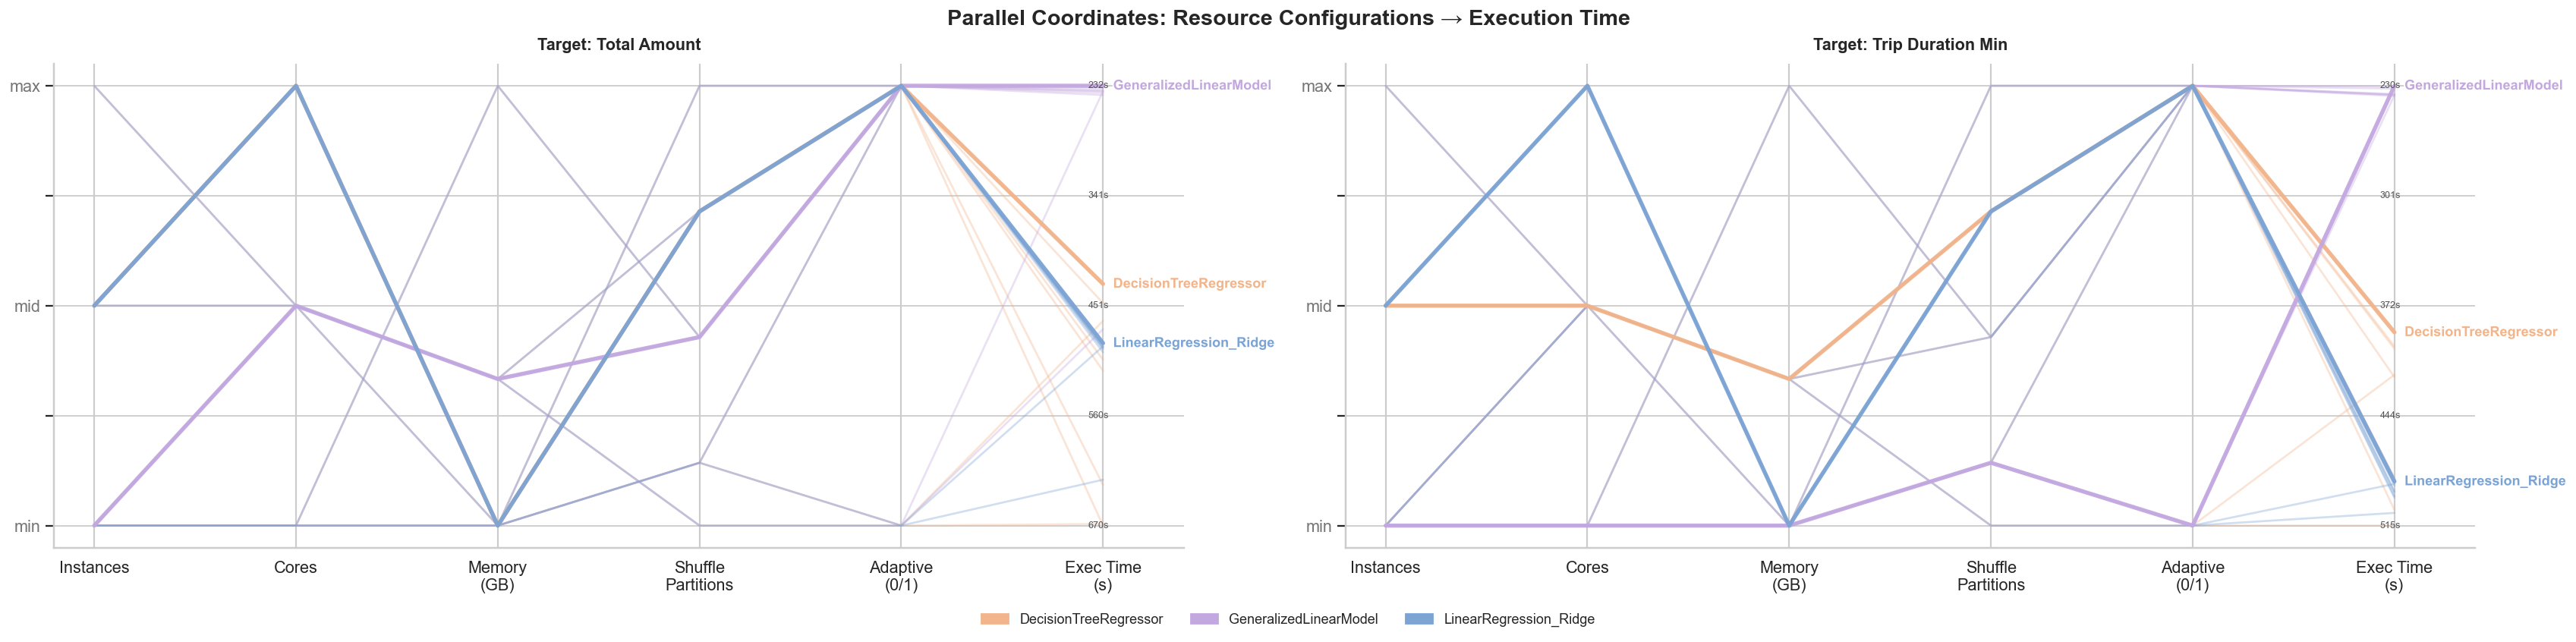

In [103]:
PC_COLS   = ["executor_instances", "executor_cores", "memory_gb",
             "shuffle_partitions", "adaptive_int", "time"]
PC_LABELS = ["Instances", "Cores", "Memory\n(GB)", "Shuffle\nPartitions",
             "Adaptive\n(0/1)", "Exec Time\n(s)"]

def norm_col(s, invert=False):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn + 1e-12)
    return 1 - n if invert else n

fig4, axes4 = plt.subplots(1, len(targets),
                            figsize=(13 * len(targets), 6),
                            constrained_layout=True)
if len(targets) == 1:
    axes4 = [axes4]

for ax, tgt in zip(axes4, targets):
    sub = df_mst[df_mst["target"] == tgt].copy().reset_index(drop=True)

    data_norm = pd.DataFrame()
    for col in PC_COLS:
        data_norm[col] = norm_col(sub[col], invert=(col == "time"))

    n_axes = len(PC_COLS)
    xs     = list(range(n_axes))

    for x in xs:
        ax.axvline(x, color="#ccc", linewidth=1.2, zorder=0)

    for i, row in data_norm.iterrows():
        model = sub.loc[i, "model_name"]
        clr   = MODEL_COLORS.get(model, "#999999")
        ys    = [row[col] for col in PC_COLS]
        ax.plot(xs, ys, color=clr, alpha=0.35, linewidth=1.5, zorder=2)

    best_per_model = sub.loc[sub.groupby("model_name")["time"].idxmin()]
    for _, best_row in best_per_model.iterrows():
        idx   = best_row.name
        model = best_row["model_name"]
        clr   = MODEL_COLORS.get(model, "#999999")
        ys    = [data_norm.loc[idx, col] for col in PC_COLS]
        ax.plot(xs, ys, color=clr, linewidth=3.0, alpha=0.95, zorder=4,
                solid_capstyle="round")
        ax.text(n_axes - 1 + 0.05, ys[-1], SHORT[model],
                va="center", ha="left", fontsize=10, color=clr, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xticks(xs)
    ax.set_xticklabels(PC_LABELS, fontsize=12)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["min", "", "mid", "", "max"], fontsize=12, color="#777")
    ax.set_xlim(-0.2, n_axes - 0.6)
    ax.set_ylim(-0.05, 1.05)

    tgt_label = tgt.replace("_", " ").title()
    ax.set_title(f"Target: {tgt_label}", fontsize=12, fontweight="bold")

    ax2 = ax.twinx()
    ax2.set_ylim(-0.05, 1.05)
    time_vals = sub["time"]
    for raw_v in np.linspace(time_vals.min(), time_vals.max(), 5):
        norm_v = 1 - (raw_v - time_vals.min()) / (time_vals.max() - time_vals.min() + 1e-12)
        ax2.text(n_axes - 0.97, norm_v, f"{raw_v:.0f}s",
                 va="center", ha="right", fontsize=7, color="#555")
    ax2.set_yticks([])
    ax2.spines["right"].set_visible(False)

legend_hdls = [mpatches.Patch(color=MODEL_COLORS.get(m, "#999"), label=SHORT[m])
               for m in models]
fig4.legend(handles=legend_hdls, loc="lower center",
            ncol=min(6, n_models), fontsize=10,
            bbox_to_anchor=(0.5, -0.07), frameon=False)
fig4.suptitle(
    "Parallel Coordinates: Resource Configurations → Execution Time",
    fontsize=16, fontweight="bold",
)
plt.show()

5. Dumbbell Chart — RMSE (●) vs MAE (■) per model, the gap Δ measures sensitivity to outliers / atypical trips

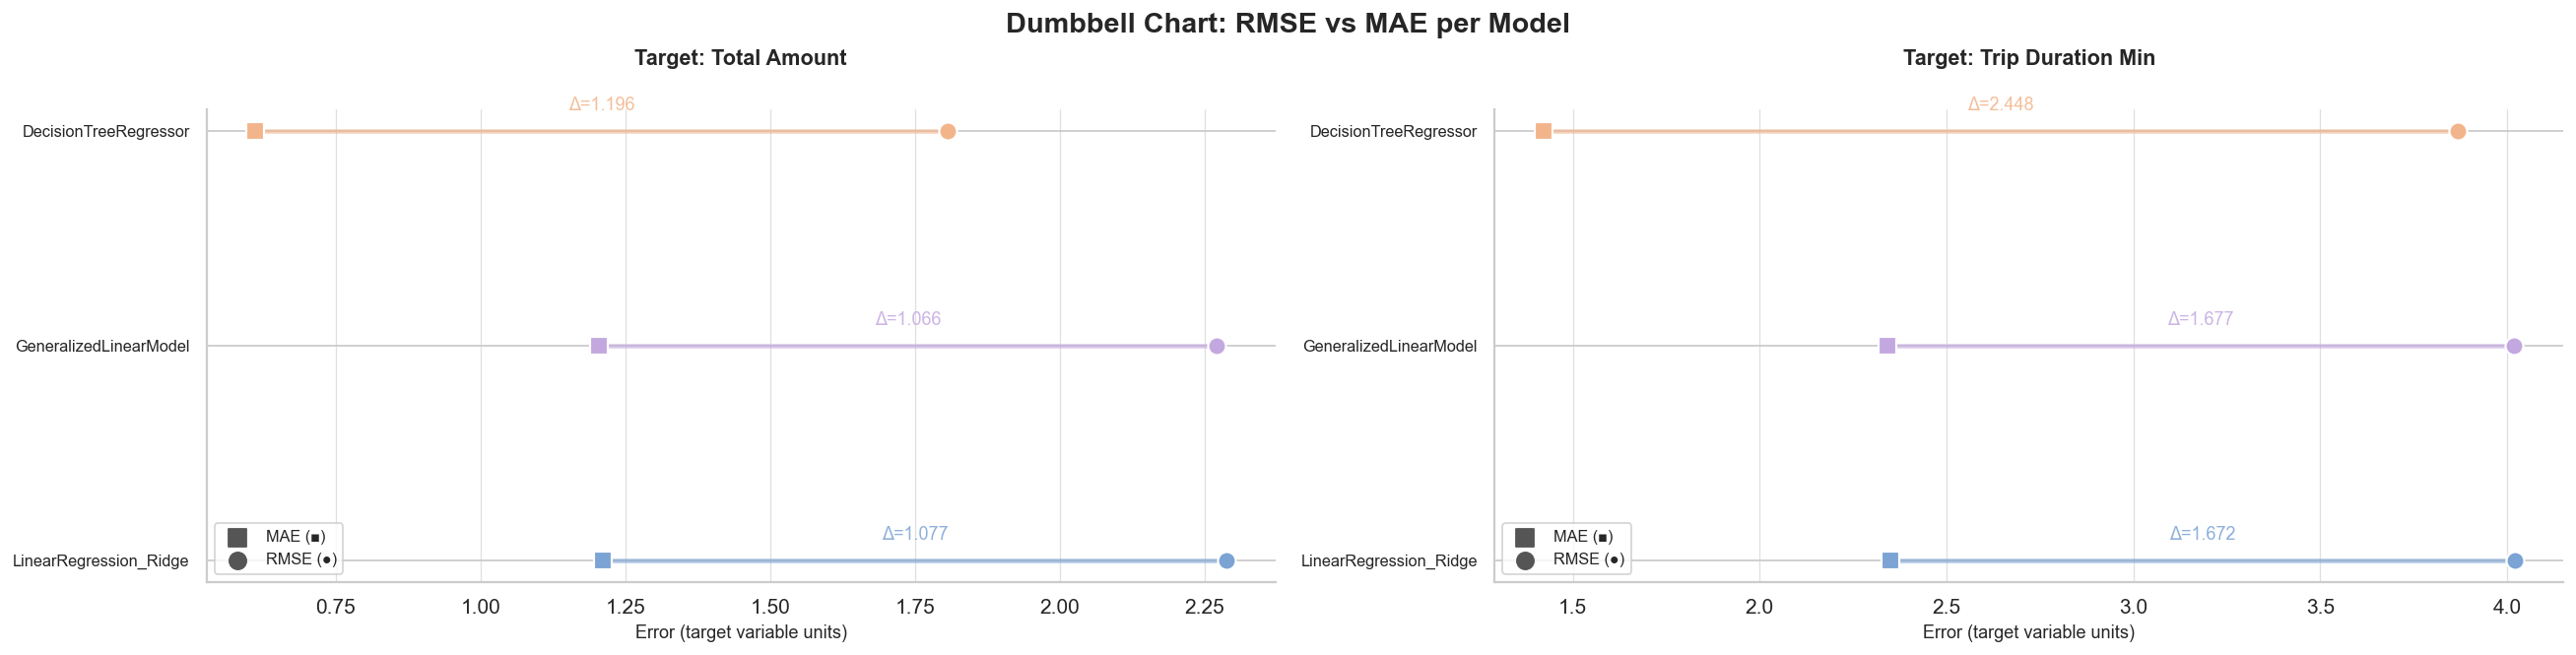

In [110]:
fig5, axes5 = plt.subplots(
    1, len(targets),
    figsize=(10 * len(targets), max(5, n_models * 0.7)),
    constrained_layout=True,
)
if len(targets) == 1:
    axes5 = [axes5]

for ax, tgt in zip(axes5, targets):
    sub = df_mta[df_mta["target"] == tgt].copy()
    sub = sub.sort_values("rmse_mean", ascending=False).reset_index(drop=True)

    y_pos = np.arange(len(sub))

    for i, row in sub.iterrows():
        clr    = MODEL_COLORS.get(row["model_name"], "#999999")
        mae_v  = row["mae_mean"]
        rmse_v = row["rmse_mean"]

        ax.hlines(y_pos[i], mae_v, rmse_v,
                  color=clr, linewidth=2.5, alpha=0.6, zorder=2)
        ax.scatter(mae_v,  y_pos[i], color=clr, s=100, marker="s",
                   zorder=4, edgecolors="white", linewidths=1.2)
        ax.scatter(rmse_v, y_pos[i], color=clr, s=100, marker="o",
                   zorder=4, edgecolors="white", linewidths=1.2)

        gap = rmse_v - mae_v
        ax.text((mae_v + rmse_v) / 2, y_pos[i] + 0.08,
                f"Δ={gap:.3f}", ha="center", va="bottom",
                fontsize=10, color=clr, alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([SHORT[m] for m in sub["model_name"]], fontsize=9)
    ax.set_xlabel("Error (target variable units)", fontsize=10)
    tgt_label = tgt.replace("_", " ").title()
    ax.set_title(f"Target: {tgt_label}", fontsize=12, fontweight="bold", pad=25)
    ax.xaxis.grid(True, color="#e0e0e0", linewidth=0.7, zorder=0)

    sq  = ax.scatter([], [], s=90, marker="s", color="#555", label="MAE (■)")
    cir = ax.scatter([], [], s=90, marker="o", color="#555", label="RMSE (●)")
    ax.legend(handles=[sq, cir], fontsize=9, loc="lower left")

fig5.suptitle(
    "Dumbbell Chart: RMSE vs MAE per Model",
    fontsize=16, fontweight="bold",
)
plt.show()

#### Final Summary

In [111]:
print("\n" + "=" * 65)
print("SUMMARY — ML MODELS")
print("=" * 65)
for tgt in targets:
    sub = df_mta[df_mta["target"] == tgt]
    best_r2   = sub.loc[sub["r2_mean"].idxmax()]
    best_time = sub.loc[sub["time_mean"].idxmin()]
    best_mae  = sub.loc[sub["mae_mean"].idxmin()]
    tgt_label = tgt.replace("_", " ").title()
    print(f"\n  Target: {tgt_label}")
    print(f"    Best R²      : {SHORT[best_r2['model_name']]:20s}  R²={best_r2['r2_mean']:.4f}")
    print(f"    Lowest MAE   : {SHORT[best_mae['model_name']]:20s}  MAE={best_mae['mae_mean']:.4f}")
    print(f"    Fastest      : {SHORT[best_time['model_name']]:20s}  t={best_time['time_mean']:.1f}s")
print("=" * 65)


SUMMARY — ML MODELS

  Target: Total Amount
    Best R²      : DecisionTreeRegressor  R²=0.9789
    Lowest MAE   : DecisionTreeRegressor  MAE=0.6112
    Fastest      : GeneralizedLinearModel  t=266.4s

  Target: Trip Duration Min
    Best R²      : DecisionTreeRegressor  R²=0.8521
    Lowest MAE   : DecisionTreeRegressor  MAE=1.4204
    Fastest      : GeneralizedLinearModel  t=233.6s
